# Group00 &middot; ds004504 &middot; Task 2a &mdash; ML Baselines
**Track:** 1 &middot; GNN on table-style EEG data &middot; **Notebook:** `task2_baselines`
**Dataset:** OpenNeuro ds004504 v1.0.9 (88 subjects: 36 AD / 23 FTD / 29 CN)

This notebook: extracts per-channel band-power features + two functional-connectivity graphs (correlation, PLV) from the raw EEG, then trains and evaluates 5 non-graph ML baselines.


In [ ]:
!apt-get update -qq
!apt-get install -y git-annex

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  aria2 git-remote-gcrypt libaria2-0 libc-ares2 netbase nocache
Suggested packages:
  xdot bup adb tor magic-wormhole tahoe-lafs libnss-mdns uftp youtube-dl
  rclone
The following NEW packages will be installed:
  aria2 git-annex git-remote-gcrypt libaria2-0 libc-ares2 netbase nocache
0 upgraded, 7 newly installed, 0 to remove and 69 not upgraded.
Need to get 14.4 MB of archives.
After this operation, 80.5 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 netbase all 6.3 [12.9 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 libc-ares2 amd64 1.18.1-1ubuntu0.22.04.3 [45.1 kB]
Get:3 http:/

In [ ]:
!git annex version

git-annex version: 8.20210223
build flags: Assistant Webapp Pairing Inotify DBus DesktopNotify TorrentParser MagicMime Feeds Testsuite S3 WebDAV
dependency versions: aws-0.22 bloomfilter-2.0.1.0 cryptonite-0.26 DAV-1.3.4 feed-1.3.0.1 ghc-8.8.4 http-client-0.6.4.1 persistent-sqlite-2.10.6.2 torrent-10000.1.1 uuid-1.3.13 yesod-1.6.1.0
key/value backends: SHA256E SHA256 SHA512E SHA512 SHA224E SHA224 SHA384E SHA384 SHA3_256E SHA3_256 SHA3_512E SHA3_512 SHA3_224E SHA3_224 SHA3_384E SHA3_384 SKEIN256E SKEIN256 SKEIN512E SKEIN512 BLAKE2B256E BLAKE2B256 BLAKE2B512E BLAKE2B512 BLAKE2B160E BLAKE2B160 BLAKE2B224E BLAKE2B224 BLAKE2B384E BLAKE2B384 BLAKE2BP512E BLAKE2BP512 BLAKE2S256E BLAKE2S256 BLAKE2S160E BLAKE2S160 BLAKE2S224E BLAKE2S224 BLAKE2SP256E BLAKE2SP256 BLAKE2SP224E BLAKE2SP224 SHA1E SHA1 MD5E MD5 WORM URL X*
remote types: git gcrypt p2p S3 bup directory rsync web bittorrent webdav adb tahoe glacier ddar git-lfs httpalso borg hook external
operating system: linux x86_64
supported reposi

In [ ]:
!pip install git-annex datalad

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.0/22.0 MB 23.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 78.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.4/101.4 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.2/148.2 kB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.6/15.6 MB 120.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 kB 11.1 MB/s eta 0:00:00


In [ ]:
!git config --global user.email "colab@example.com"
!git config --global user.name "Colab User"

!datalad install https://github.com/OpenNeuroDatasets/ds004504.git

Cloning:   0% 0.00/2.00 [00:00<?, ? candidates/s]
Enumerating: 0.00 Objects [00:00, ? Objects/s]
                                              
Counting:   0% 0.00/1.19k [00:00<?, ? Objects/s]
                                                
Compressing:   0% 0.00/586 [00:00<?, ? Objects/s]
                                                 
Receiving:   0% 0.00/3.60k [00:00<?, ? Objects/s]
Receiving:  10% 360/3.60k [00:00<00:01, 1.97k Objects/s]
Receiving:  38% 1.37k/3.60k [00:00<00:00, 3.92k Objects/s]
Receiving:  69% 2.48k/3.60k [00:00<00:00, 4.79k Objects/s]
                                                          
Resolving:   0% 0.00/855 [00:00<?, ? Deltas/s]
[INFO   ] Remote origin not usable by git-annex; setting annex-ignore 
[INFO   ] https://github.com/OpenNeuroDatasets/ds004504.git/config download failed: Not Found 
[INFO   ] Remote origin not usable by git-annex; setting annex-ignore 
[INFO   ] https://github.com/OpenNeuroDatasets/ds004504.git/config download failed: Not Fo

In [ ]:
%cd ds004504

!datalad get sub-*/eeg/*.set

/content/ds004504
Total:   0% 0.00/2.83G [00:00<?, ? Bytes/s]
Total:   0% 16.4k/2.83G [00:01<?, ? Bytes/s]
Get sub-034/ .. osed_eeg.set:   0% 33.3k/38.9M [00:00<08:31, 76.0k Bytes/s]
Get sub-034/ .. osed_eeg.set:   0% 69.9k/38.9M [00:00<05:04, 128k Bytes/s] 
Total:   0% 139k/2.83G [00:01<11:39:43, 67.4k Bytes/s]
Get sub-034/ .. osed_eeg.set:   1% 279k/38.9M [00:00<01:43, 375k Bytes/s]
Get sub-034/ .. osed_eeg.set:   1% 557k/38.9M [00:01<00:55, 689k Bytes/s]
Total:   0% 1.03M/2.83G [00:02<1:56:27, 405k Bytes/s] 
Get sub-034/ .. osed_eeg.set:   5% 1.98M/38.9M [00:01<00:16, 2.18M Bytes/s]
Get sub-034/ .. osed_eeg.set:  10% 3.85M/38.9M [00:01<00:08, 4.15M Bytes/s]
Total:   0% 6.01M/2.83G [00:03<24:26, 1.93M Bytes/s] 
Get sub-034/ .. osed_eeg.set:  21% 8.08M/38.9M [00:02<00:04, 6.78M Bytes/s]
Get sub-034/ .. osed_eeg.set:  26% 10.2M/38.9M [00:02<00:03, 7.65M Bytes/s]
Get sub-034/ .. osed_eeg.set:  32% 12.4M/38.9M [00:02<00:03, 8.23M Bytes/s]
Get sub-034/ .. osed_eeg.set:  37% 14.4M/38.9M [0

In [ ]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import time
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                              classification_report, confusion_matrix, roc_curve, auc)

np.random.seed(42)
sns.set_theme(style="whitegrid")
GROUP_ORDER = ["A", "F", "C"]
GROUP_NAMES = {"A": "Alzheimer's (AD)", "F": "Frontotemporal Dementia (FTD)", "C": "Healthy Control (CN)"}
GROUP_COLORS = {"A": "#d1495b", "F": "#edae49", "C": "#00798c"}
LABEL_MAP = {g: i for i, g in enumerate(GROUP_ORDER)}

# ---- paths & mode detection --------------------------------------------------
RAW_DIR = Path("/content/ds004504")                 # <- your real Colab download
FEATURE_CACHE = Path("features_cache.npz")           # produced by this notebook
DEMO_CACHE = Path("demo_synthetic_features.npz")     # bundled fallback

if RAW_DIR.exists():
    MODE = "REAL"
    print(f"[MODE] Real raw EEG found at {RAW_DIR} -> extracting from actual signal.")
elif DEMO_CACHE.exists():
    MODE = "DEMO"
    print(f"[MODE] {RAW_DIR} not found -> falling back to bundled SYNTHETIC DEMO cache "
          f"({DEMO_CACHE}). Results below are placeholders, not real EEG findings.")
else:
    raise FileNotFoundError(
        "Neither the real dataset nor the demo cache was found. Set RAW_DIR to your "
        "ds004504 folder, or make sure demo_synthetic_features.npz sits next to this notebook."
    )


[MODE] Real raw EEG found at /content/ds004504 -> extracting from actual signal.


## Feature extraction pipeline
Per subject: band-pass filter (0.5&ndash;45&nbsp;Hz) &rarr; fixed-length 8s epochs &rarr; Welch PSD per channel &rarr; **relative band power** in 5 canonical bands (delta/theta/alpha/beta/gamma) averaged over epochs &rarr; **19&times;5 node-feature matrix**. Two functional-connectivity (FC) graphs are computed and cached per subject &mdash; **Pearson correlation** (broadband) and **PLV** (alpha band) &mdash; because related-work Paper 1 (Klepl et al., 2022) found no single FC estimator consistently wins, so both are kept for Task 3's ablation rather than picking one upfront.

In [ ]:
BANDS = {"delta": (0.5, 4), "theta": (4, 8), "alpha": (8, 13), "beta": (13, 25), "gamma": (25, 45)}
EPOCH_LEN = 8.0
CH_NAMES_19 = ["Fp1","Fp2","F3","F4","F7","F8","T3","T4","C3","C4",
               "T5","T6","P3","P4","O1","O2","Fz","Cz","Pz"]

if MODE == "REAL":
    import mne
    mne.set_log_level("ERROR")
    from scipy.signal import hilbert

    def load_and_epoch(set_path, epoch_len=EPOCH_LEN):
        raw = mne.io.read_raw_eeglab(set_path, preload=True, verbose=False)
        raw.filter(0.5, 45.0, verbose=False)
        return mne.make_fixed_length_epochs(raw, duration=epoch_len, preload=True, verbose=False)

    def band_power_node_features(epochs):
        psd = epochs.compute_psd(method="welch", fmin=0.5, fmax=45.0, verbose=False)
        psds, freqs = psd.get_data(return_freqs=True)
        total = psds.sum(axis=-1, keepdims=True)
        mats = []
        for band, (lo, hi) in BANDS.items():
            mask = (freqs >= lo) & (freqs < hi)
            rel = psds[:, :, mask].sum(-1) / total.squeeze(-1)
            mats.append(rel.mean(axis=0))
        return np.stack(mats, axis=1)  # (n_channels, n_bands)

    def connectivity_correlation(epochs):
        data = epochs.get_data()
        return np.mean([np.corrcoef(ep) for ep in data], axis=0)

    def connectivity_plv(epochs, band=(8, 13)):
        data = epochs.copy().filter(band[0], band[1], verbose=False).get_data()
        n_ep, n_ch, _ = data.shape
        plv = np.zeros((n_ch, n_ch))
        for ep in data:
            phase = np.angle(hilbert(ep, axis=-1))
            diff = phase[:, None, :] - phase[None, :, :]
            plv += np.abs(np.mean(np.exp(1j * diff), axis=-1))
        return plv / n_ep

    participants = pd.read_csv(RAW_DIR / "participants.tsv", sep="\t")
    t0 = time.time()
    node_feat_list, corr_list, plv_list, ok_ids = [], [], [], []
    for i, row in participants.iterrows():
        sid = row["participant_id"]
        set_path = RAW_DIR / sid / "eeg" / f"{sid}_task-eyesclosed_eeg.set"
        if not set_path.exists():
            print(f"  [skip] {sid}: file not found at {set_path}")
            continue
        epochs = load_and_epoch(set_path)
        node_feat_list.append(band_power_node_features(epochs))
        corr_list.append(connectivity_correlation(epochs))
        plv_list.append(connectivity_plv(epochs))
        ok_ids.append(sid)
        if (i + 1) % 10 == 0:
            print(f"  extracted {i+1}/{len(participants)} subjects "
                  f"({time.time()-t0:.0f}s elapsed)")

    node_feats = np.stack(node_feat_list)
    corr_adj = np.stack(corr_list)
    plv_adj = np.stack(plv_list)
    participant_id = np.array(ok_ids)
    group = participants.set_index("participant_id").loc[ok_ids, "Group"].values

    np.savez_compressed(FEATURE_CACHE, node_feats=node_feats, corr_adj=corr_adj, plv_adj=plv_adj,
                         participant_id=participant_id, group=group)
    print(f"\nExtraction complete in {time.time()-t0:.0f}s -> cached to {FEATURE_CACHE}")

else:  # MODE == "DEMO"
    cache = np.load(DEMO_CACHE, allow_pickle=True)
    node_feats = cache["node_feats"]
    corr_adj = cache["corr_adj"]
    plv_adj = cache["plv_adj"]
    participant_id = cache["participant_id"]
    group = cache["group"]
    print(f"[DEMO] Loaded {len(participant_id)} synthetic subjects from cache (no real signal used).")

y = np.array([LABEL_MAP[g] for g in group])
n_subj, n_ch, n_bands = node_feats.shape
print(f"\nnode_feats: {node_feats.shape}  corr_adj: {corr_adj.shape}  plv_adj: {plv_adj.shape}")
print("Class counts:", {g: int((group == g).sum()) for g in GROUP_ORDER})


  extracted 10/88 subjects (68s elapsed)
  extracted 20/88 subjects (151s elapsed)
  extracted 30/88 subjects (223s elapsed)
  extracted 40/88 subjects (304s elapsed)
  extracted 50/88 subjects (383s elapsed)
  extracted 60/88 subjects (457s elapsed)
  extracted 70/88 subjects (522s elapsed)
  extracted 80/88 subjects (596s elapsed)

Extraction complete in 648s -> cached to features_cache.npz

node_feats: (88, 19, 5)  corr_adj: (88, 19, 19)  plv_adj: (88, 19, 19)
Class counts: {'A': 36, 'F': 23, 'C': 29}


## Subject-wise split & scaling
One row = one subject (features are already aggregated across that subject's own epochs), so an ordinary **stratified** split is leakage-safe here &mdash; no subject's data appears in more than one split. (If features were kept at the *epoch* level instead, `GroupKFold`/grouped splitting by `participant_id` would be mandatory to avoid a subject leaking across train/test.) All scaling statistics are fit on the **training subjects only**.

In [ ]:
idx = np.arange(n_subj)
train_idx, test_idx = train_test_split(idx, test_size=0.2, stratify=y, random_state=42)
train_idx, val_idx = train_test_split(train_idx, test_size=0.15, stratify=y[train_idx], random_state=42)
print(f"train={len(train_idx)}  val={len(val_idx)}  test={len(test_idx)}")
print("Train class counts:", {GROUP_ORDER[c]: int((y[train_idx]==c).sum()) for c in range(3)})
print("Test  class counts:", {GROUP_ORDER[c]: int((y[test_idx]==c).sum()) for c in range(3)})

FEATURE_NAMES = [f"{ch}_{b}" for ch in CH_NAMES_19 for b in BANDS]
X_flat = node_feats.reshape(n_subj, -1)          # (n_subj, 95) -- 19 channels x 5 bands
scaler = StandardScaler().fit(X_flat[train_idx])
X_scaled = scaler.transform(X_flat)
print(f"\nFeature matrix: {X_scaled.shape}  ({len(FEATURE_NAMES)} channel x band features)")


train=59  val=11  test=18
Train class counts: {'A': 25, 'F': 15, 'C': 19}
Test  class counts: {'A': 7, 'F': 5, 'C': 6}

Feature matrix: (88, 95)  (95 channel x band features)


## Train 5 baseline classifiers
Logistic Regression, SVM (RBF kernel), Random Forest, XGBoost, and an MLP &mdash; all class-weighted to account for the mild 36/23/29 imbalance (Task 1, Section D), all trained on the identical 95-dim scaled feature vector so the comparison to the GNN in the next notebook is apples-to-apples.

In [ ]:
baselines = {
    "LogReg": LogisticRegression(max_iter=3000, class_weight="balanced", random_state=42),
    "SVM-RBF": SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=42),
    "XGBoost": XGBClassifier(n_estimators=200, max_depth=4, eval_metric="mlogloss", random_state=42),
    "MLP": MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=3000, random_state=42),
}

fitted = {}
rows = []
for name, clf in baselines.items():
    clf.fit(X_scaled[train_idx], y[train_idx])
    fitted[name] = clf
    pred = clf.predict(X_scaled[test_idx])
    rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y[test_idx], pred),
        "Macro-F1": f1_score(y[test_idx], pred, average="macro"),
        "Macro-Precision": precision_score(y[test_idx], pred, average="macro"),
        "Macro-Recall": recall_score(y[test_idx], pred, average="macro"),
    })

results_table = pd.DataFrame(rows).set_index("Model").round(3).sort_values("Macro-F1", ascending=False)
results_table


,Accuracy,Macro-F1,Macro-Precision,Macro-Recall
Model,,,,
SVM-RBF,0.611,0.595,0.594,0.602
LogReg,0.500,0.464,0.469,0.471
MLP,0.500,0.458,0.463,0.471
XGBoost,0.444,0.383,0.357,0.413
RandomForest,0.444,0.357,0.315,0.413


In [ ]:
best_name = results_table.index[0]
best_clf = fitted[best_name]
print(f"Best baseline by macro-F1: {best_name}\n")
print(classification_report(y[test_idx], best_clf.predict(X_scaled[test_idx]),
                             target_names=[GROUP_NAMES[g] for g in GROUP_ORDER]))


Best baseline by macro-F1: SVM-RBF

                               precision    recall  f1-score   support

             Alzheimer's (AD)       0.67      0.57      0.62         7
Frontotemporal Dementia (FTD)       0.40      0.40      0.40         5
         Healthy Control (CN)       0.71      0.83      0.77         6

                     accuracy                           0.61        18
                    macro avg       0.59      0.60      0.59        18
                 weighted avg       0.61      0.61      0.61        18



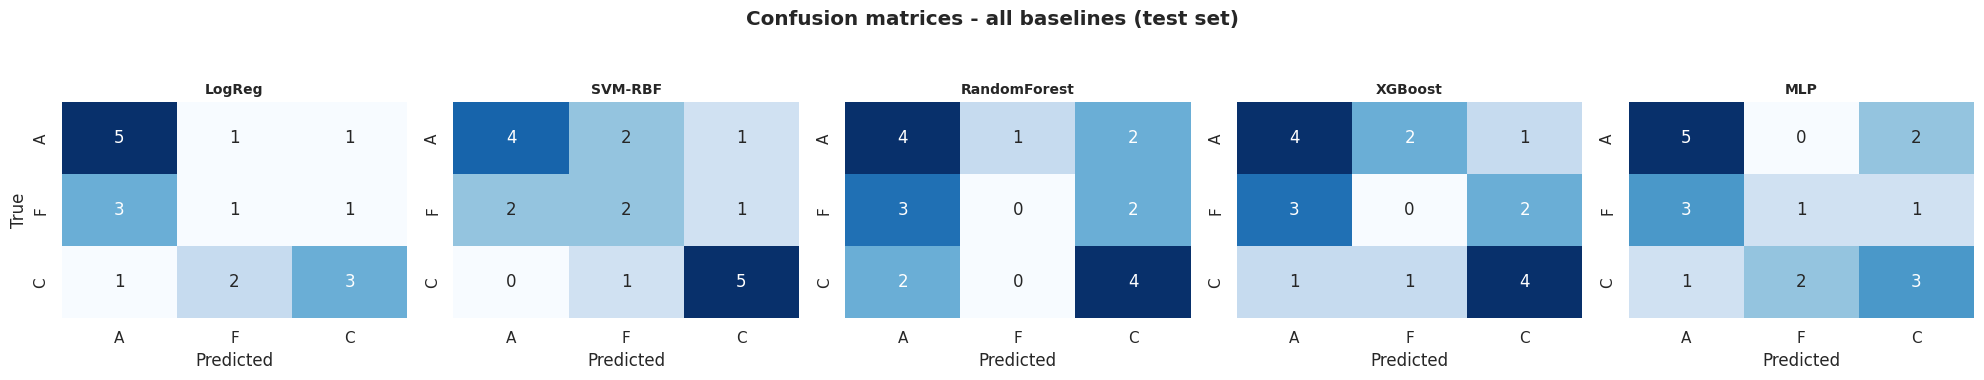

In [ ]:
fig, axes = plt.subplots(1, len(baselines), figsize=(4*len(baselines), 3.6))
for ax, (name, clf) in zip(axes, fitted.items()):
    cm = confusion_matrix(y[test_idx], clf.predict(X_scaled[test_idx]))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=GROUP_ORDER, yticklabels=GROUP_ORDER)
    ax.set_title(name, fontsize=10, fontweight="bold")
    ax.set_xlabel("Predicted"); ax.set_ylabel("True" if ax is axes[0] else "")
plt.suptitle("Confusion matrices - all baselines (test set)", fontweight="bold", y=1.05)
plt.tight_layout()
plt.show()


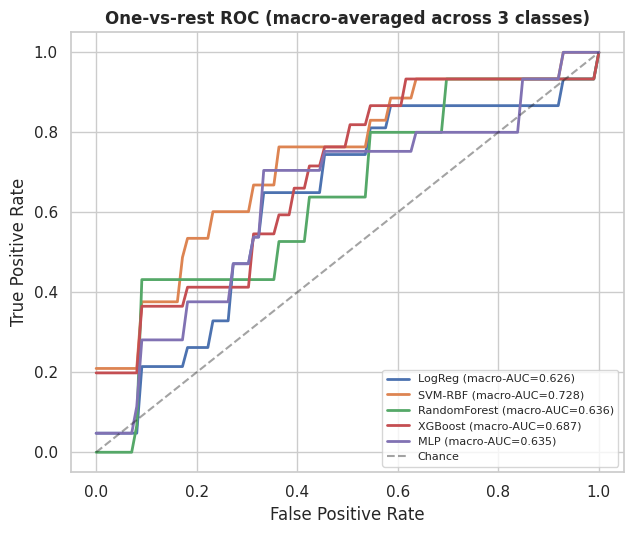

In [ ]:
y_test_bin = label_binarize(y[test_idx], classes=[0, 1, 2])
fig, ax = plt.subplots(figsize=(6.5, 5.5))
for name, clf in fitted.items():
    if not hasattr(clf, "predict_proba"):
        continue
    proba = clf.predict_proba(X_scaled[test_idx])
    fpr, tpr = dict(), dict()
    aucs = []
    for c in range(3):
        fpr[c], tpr[c], _ = roc_curve(y_test_bin[:, c], proba[:, c])
        aucs.append(auc(fpr[c], tpr[c]))
    macro_auc = np.mean(aucs)
    mean_fpr = np.linspace(0, 1, 100)
    mean_tpr = np.mean([np.interp(mean_fpr, fpr[c], tpr[c]) for c in range(3)], axis=0)
    ax.plot(mean_fpr, mean_tpr, label=f"{name} (macro-AUC={macro_auc:.3f})", linewidth=2)
ax.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Chance")
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("One-vs-rest ROC (macro-averaged across 3 classes)", fontweight="bold")
ax.legend(fontsize=8, loc="lower right")
plt.tight_layout()
plt.show()


## Summary
5 non-graph baselines trained on the identical 95-dim (19 channel &times; 5 band) feature vector the GNN will use as node features, evaluated with macro-F1/precision/recall (not plain accuracy, given the 36/23/29 imbalance from Task 1).

